<a href="https://colab.research.google.com/github/coderKC1999/Pytorch_Learning_01/blob/main/DLCV_U1L1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import time

start=time.time()
print(start)

1789238727.7113714


In [3]:
import torch

In [4]:
t1 = torch.tensor([1,2,3])
t2 = torch.tensor([4,5,6])
res = t1+t2
print(res)

tensor([5, 7, 9])


In [7]:
t3 = torch.tensor([[1,2,3],[4,5,6]])
reshaped_t3 = t3.view(3,2)
print(reshaped_t3)

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [32]:
# FOllowing is the Simple NN for XOR gate by network itself from training

import torch
import torch.nn as nn
import torch.optim as optim

class SimpleNN(nn.Module):
  def __init__(self):
    super(SimpleNN, self).__init__()
    self.hidden = nn.Linear(2,3)    # Input to Hidden
    self.output = nn.Linear(3,1)   # Hidden to Ouptut

  def forward(self,x):
    x = torch.relu(self.hidden(x))
    x = torch.sigmoid(self.output(x))
    return x

In [33]:
input = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
labels = torch.tensor([[0],[1],[1],[0]], dtype = torch.float32)



In [34]:
model = SimpleNN()
loss_fun = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

# Training loop
for epoch in range(1000):
  optimizer.zero_grad()
  output = model(input)
  loss = loss_fun(output, labels)
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.2514881491661072
Epoch 100, Loss: 0.22179150581359863
Epoch 200, Loss: 0.20057952404022217
Epoch 300, Loss: 0.17979326844215393
Epoch 400, Loss: 0.1627885401248932
Epoch 500, Loss: 0.15003323554992676
Epoch 600, Loss: 0.14064271748065948
Epoch 700, Loss: 0.1316051483154297
Epoch 800, Loss: 0.11751052737236023
Epoch 900, Loss: 0.09220803529024124


In [35]:
predictions = model(input)
print(predictions)

tensor([[0.1435],
        [0.9080],
        [0.6954],
        [0.3814]], grad_fn=<SigmoidBackward0>)


In [36]:
model.eval()
with torch.no_grad():
    hidden_out = torch.relu(model.hidden(input))
    print(hidden_out)

tensor([[1.0606e+00, 0.0000e+00, 4.9909e-01],
        [9.2447e-04, 1.3975e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0857e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]])


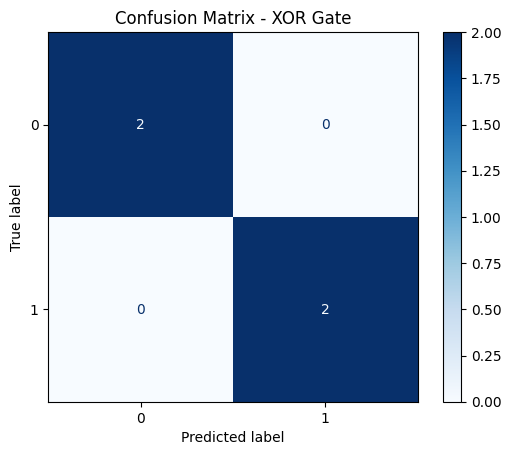

Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
True labels:
 [0. 1. 1. 0.]
Predicted:
 [0. 1. 1. 0.]
Raw outputs:
 [0.14345022 0.90801334 0.6954362  0.3813878 ]


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get model predictions
model.eval()
with torch.no_grad():
    outputs = model(input)
    predictions = (outputs >= 0.5).float()

# Convert to numpy for sklearn
y_true = labels.numpy().flatten()
y_pred = predictions.numpy().flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XOR Gate')
plt.show()

# Print raw predictions for reference
print("Inputs:\n", input.numpy())
print("True labels:\n", y_true)
print("Predicted:\n", y_pred)
print("Raw outputs:\n", outputs.numpy().flatten())

In [47]:
class SimpleNN2(nn.Module):
  def __init__(self):
    super(SimpleNN2, self).__init__()
    self.hidden = nn.Linear(2,10)    # Input to Hidden
    self.output = nn.Linear(10,1)   # Hidden to Ouptut

  def forward(self,x):
    x = torch.relu(self.hidden(x))
    x = torch.sigmoid(self.output(x))
    return x

model = SimpleNN2()
loss_fun = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

# Training loop
for epoch in range(1000):
  optimizer.zero_grad()
  output = model(input)
  loss = loss_fun(output, labels)
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.2369357794523239
Epoch 100, Loss: 0.20301519334316254
Epoch 200, Loss: 0.15892493724822998
Epoch 300, Loss: 0.11717492341995239
Epoch 400, Loss: 0.08092775195837021
Epoch 500, Loss: 0.05451369285583496
Epoch 600, Loss: 0.03715994954109192
Epoch 700, Loss: 0.026347167789936066
Epoch 800, Loss: 0.01948811300098896
Epoch 900, Loss: 0.01499317679554224


In [48]:
model.eval()
with torch.no_grad():
    hidden_out = torch.relu(model.hidden(input))
    print(hidden_out)

tensor([[0.0000e+00, 0.0000e+00, 2.7553e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         1.1920e+00, 3.8931e-03, 0.0000e+00, 3.5966e-01],
        [1.0806e-03, 1.2162e-03, 6.5329e-02, 0.0000e+00, 0.0000e+00, 1.3643e+00,
         5.8532e-05, 1.5792e-01, 1.1951e-04, 0.0000e+00],
        [0.0000e+00, 4.1246e-04, 3.7700e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         2.3735e-04, 8.4451e-01, 0.0000e+00, 1.4723e+00],
        [9.9009e-01, 1.0544e+00, 1.6680e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 9.9854e-01, 6.1320e-01, 1.0825e+00]])


In [49]:
predictions = model(input)
print(predictions)

tensor([[0.1132],
        [0.9167],
        [0.8674],
        [0.0998]], grad_fn=<SigmoidBackward0>)


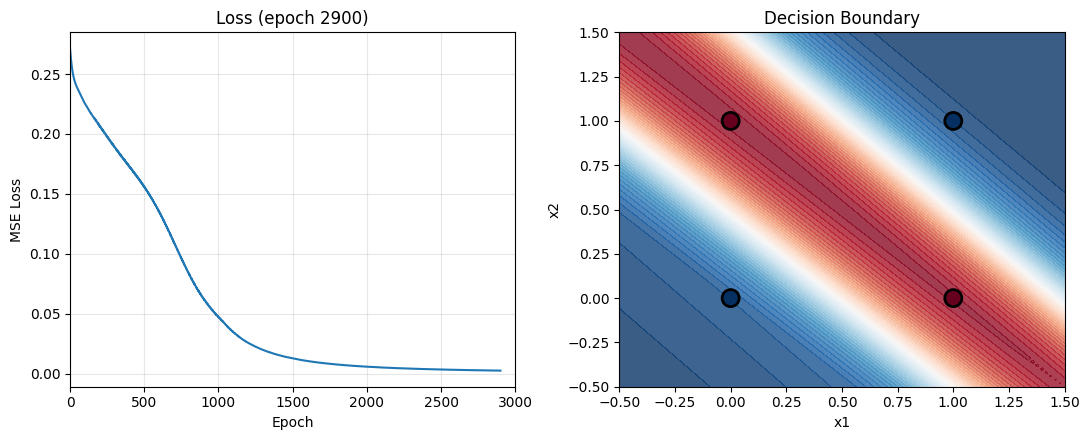

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch
import torch.nn as nn

# Re-init model fresh
torch.manual_seed(42)
model = SimpleNN()
loss_fun = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

input = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
labels = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# Grid for decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

losses = []

for epoch in range(3000):
    optimizer.zero_grad()
    output = model(input)
    loss = loss_fun(output, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 100 == 0:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

        # --- Loss curve ---
        axes[0].plot(losses, color='tab:blue')
        axes[0].set_title(f'Loss (epoch {epoch})')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('MSE Loss')
        axes[0].set_xlim(0, 3000)
        axes[0].grid(alpha=0.3)

        # --- Decision boundary ---
        with torch.no_grad():
            preds = model(grid).reshape(xx.shape)
        axes[1].contourf(xx, yy, preds, levels=50, cmap='RdBu_r', alpha=0.8, vmin=0, vmax=1)
        axes[1].scatter(input[:,0], input[:,1], c=labels.flatten(), cmap='RdBu_r',
                         edgecolors='black', s=150, linewidths=2)
        axes[1].set_title('Decision Boundary')
        axes[1].set_xlabel('x1')
        axes[1].set_ylabel('x2')

        plt.tight_layout()
        plt.show()